In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

Web Scraping dari wikipedia planet minor, menggunakan beautifulsoup

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_minor_planets:_1%E2%80%931000"

print(url)

https://en.wikipedia.org/wiki/List_of_minor_planets:_1%E2%80%931000


In [3]:
headers = {
    "User-Agent": "Mozilla/5.0 (Educational Data Analysis Project)"
}

response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)

Status Code: 200


In [4]:
print(response.text[:500])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientp


In [5]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title)

<title>List of minor planets: 1–1000 - Wikipedia</title>


In [6]:
tables = soup.find_all("table", class_="wikitable")

print("Jumlah tabel ditemukan:", len(tables))

Jumlah tabel ditemukan: 10


In [7]:
first_table = tables[0]

rows = first_table.find_all("tr")

print("Jumlah baris HTML pada tabel pertama:", len(rows))

Jumlah baris HTML pada tabel pertama: 103


In [8]:
for i, row in enumerate(rows[:6]):
    cells = row.find_all(["th", "td"])
    values = [cell.get_text(" ", strip=True) for cell in cells]

    print("Baris", i, ":", values)

Baris 0 : ['Designation', 'Discovery', 'Properties', 'Ref']
Baris 1 : ['Permanent', 'Provisional', 'Named after', 'Date', 'Site', 'Discoverer(s)', 'Category', 'Diam.']
Baris 2 : ['', '', '', '', '', '', '', '']
Baris 3 : ['1 Ceres', '—', 'Ceres', 'January 1, 1801', 'Palermo', 'G. Piazzi', '·', '939 km (583 mi)', 'MPC · JPL']
Baris 4 : ['2 Pallas', '—', 'Pallas', 'March 28, 1802', 'Bremen', 'H. W. Olbers', 'PAL', '513 km (319 mi)', 'MPC · JPL']
Baris 5 : ['3 Juno', '—', 'Juno', 'September 1, 1804', 'Sternwarte Lilienthal', 'K. Harding', 'JUN', '247 km (153 mi)', 'MPC · JPL']


In [9]:
# Nama kolom yang akan digunakan pada dataset
columns = [
    "Permanent",
    "Provisional",
    "Named_After",
    "Discovery_Date",
    "Discovery_Site",
    "Discoverer",
    "Category",
    "Diameter",
    "Reference"
]

data_first_table = []

# Membaca setiap baris dari tabel pertama
for row in first_table.find_all("tr"):
    cells = row.find_all("td")

    # Mengambil teks dari setiap cell
    values = [cell.get_text(" ", strip=True) for cell in cells]

    # Baris data minor planet memiliki 9 kolom
    if len(values) == 9:
        data_first_table.append(values)

# Membuat DataFrame
df_first_table = pd.DataFrame(data_first_table, columns=columns)

print("Ukuran tabel pertama:", df_first_table.shape)

df_first_table.head()

Ukuran tabel pertama: (100, 9)


,Permanent,Provisional,Named_After,Discovery_Date,Discovery_Site,Discoverer,Category,Diameter,Reference
0,1 Ceres,—,Ceres,"January 1, 1801",Palermo,G. Piazzi,·,939 km (583 mi),MPC · JPL
1,2 Pallas,—,Pallas,"March 28, 1802",Bremen,H. W. Olbers,PAL,513 km (319 mi),MPC · JPL
2,3 Juno,—,Juno,"September 1, 1804",Sternwarte Lilienthal,K. Harding,JUN,247 km (153 mi),MPC · JPL
3,4 Vesta,—,Vesta,"March 29, 1807",Bremen,H. W. Olbers,V,523 km (325 mi),MPC · JPL
4,5 Astraea,—,Astraea,"December 8, 1845",Driesen,K. L. Hencke,(5),107 km (66 mi),MPC · JPL


In [10]:
df_first_table.tail()

,Permanent,Provisional,Named_After,Discovery_Date,Discovery_Site,Discoverer,Category,Diameter,Reference
95,96 Aegle,—,Aegle,"February 17, 1868",Marseilles,J. Coggia,AEG,178 km (111 mi),MPC · JPL
96,97 Klotho,—,Klotho,"February 17, 1868",Marseilles,E. W. Tempel,·,101 km (63 mi),MPC · JPL
97,98 Ianthe,—,Ianthe,"April 18, 1868",Clinton,C. H. F. Peters,·,133 km (83 mi),MPC · JPL
98,99 Dike,—,Dike,"May 28, 1868",Marseilles,A. Borrelly,·,67 km (42 mi),MPC · JPL
99,100 Hekate,—,Hekate,"July 11, 1868",Ann Arbor,J. C. Watson,HYG ·,86 km (53 mi),MPC · JPL


In [11]:
all_data_1000 = []

# Melakukan perulangan untuk seluruh 10 tabel
for table in tables:

    # Mengambil seluruh baris pada tabel
    rows = table.find_all("tr")

    for row in rows:

        # Hanya mengambil cell data <td>
        cells = row.find_all("td")

        # Membersihkan teks
        values = [cell.get_text(" ", strip=True) for cell in cells]

        # Hanya mengambil baris yang memiliki 9 kolom
        if len(values) == 9:
            all_data_1000.append(values)

# Mengubah hasil scraping menjadi DataFrame
df_1000 = pd.DataFrame(all_data_1000, columns=columns)

print("Ukuran dataset:", df_1000.shape)

Ukuran dataset: (1000, 9)


In [12]:
df_1000.head()

,Permanent,Provisional,Named_After,Discovery_Date,Discovery_Site,Discoverer,Category,Diameter,Reference
0,1 Ceres,—,Ceres,"January 1, 1801",Palermo,G. Piazzi,·,939 km (583 mi),MPC · JPL
1,2 Pallas,—,Pallas,"March 28, 1802",Bremen,H. W. Olbers,PAL,513 km (319 mi),MPC · JPL
2,3 Juno,—,Juno,"September 1, 1804",Sternwarte Lilienthal,K. Harding,JUN,247 km (153 mi),MPC · JPL
3,4 Vesta,—,Vesta,"March 29, 1807",Bremen,H. W. Olbers,V,523 km (325 mi),MPC · JPL
4,5 Astraea,—,Astraea,"December 8, 1845",Driesen,K. L. Hencke,(5),107 km (66 mi),MPC · JPL


In [13]:
df_1000.tail()

,Permanent,Provisional,Named_After,Discovery_Date,Discovery_Site,Discoverer,Category,Diameter,Reference
995,996 Hilaritas,1923 NM,Hilaritas,"March 21, 1923",Vienna,J. Palisa,THM,29 km (18 mi),MPC · JPL
996,997 Priska,1923 NR,Priska,"July 12, 1923",Heidelberg,K. Reinmuth,ADE,20 km (12 mi),MPC · JPL
997,998 Bodea,1923 NU,Bodea,"August 6, 1923",Heidelberg,K. Reinmuth,·,32 km (20 mi),MPC · JPL
998,999 Zachia,1923 NW,Zachia,"August 9, 1923",Heidelberg,K. Reinmuth,·,17 km (11 mi),MPC · JPL
999,1000 Piazzia,1923 NZ,Piazzia,"August 12, 1923",Heidelberg,K. Reinmuth,·,48 km (30 mi),MPC · JPL


In [14]:
for i, table in enumerate(tables, start=1):

    jumlah_data = 0

    for row in table.find_all("tr"):
        cells = row.find_all("td")

        if len(cells) == 9:
            jumlah_data += 1

    print(f"Tabel {i}: {jumlah_data} data")

Tabel 1: 100 data
Tabel 2: 100 data
Tabel 3: 100 data
Tabel 4: 100 data
Tabel 5: 100 data
Tabel 6: 100 data
Tabel 7: 100 data
Tabel 8: 100 data
Tabel 9: 100 data
Tabel 10: 100 data


In [15]:
def scrape_minor_planets(url):

    # Mengambil halaman website
    response = requests.get(url, headers=headers)

    print("Status Code:", response.status_code)

    # Membaca HTML menggunakan BeautifulSoup
    soup = BeautifulSoup(response.text, "html.parser")

    # Mencari seluruh tabel wikitable
    tables = soup.find_all("table", class_="wikitable")

    print("Jumlah tabel ditemukan:", len(tables))

    data = []

    # Mengambil data dari setiap tabel
    for table in tables:

        for row in table.find_all("tr"):

            cells = row.find_all("td")

            values = [
                cell.get_text(" ", strip=True)
                for cell in cells
            ]

            if len(values) == 9:
                data.append(values)

    # Mengubah menjadi DataFrame
    df = pd.DataFrame(data, columns=columns)

    return df

In [17]:
url_1 = "https://en.wikipedia.org/wiki/List_of_minor_planets:_1%E2%80%931000"

df_part1 = scrape_minor_planets(url_1)

print("Jumlah data halaman pertama:", df_part1.shape)

Status Code: 200
Jumlah tabel ditemukan: 10
Jumlah data halaman pertama: (1000, 9)


1001-2000

In [18]:
url_2 = "https://en.wikipedia.org/wiki/List_of_minor_planets:_1001%E2%80%932000"

df_part2 = scrape_minor_planets(url_2)

print("Jumlah data halaman kedua:", df_part2.shape)

Status Code: 200
Jumlah tabel ditemukan: 10
Jumlah data halaman kedua: (1000, 9)


Menggabungkan dua dataset

In [19]:
df_raw = pd.concat(
    [df_part1, df_part2],
    ignore_index=True
)

print("Ukuran dataset akhir:", df_raw.shape)

Ukuran dataset akhir: (2000, 9)


Melihat isi dataset gabungan

In [21]:
print("5 data pertama:")
display(df_raw.head())

print("\n5 data terakhir:")
display(df_raw.tail())

5 data pertama:


,Permanent,Provisional,Named_After,Discovery_Date,Discovery_Site,Discoverer,Category,Diameter,Reference
0,1 Ceres,—,Ceres,"January 1, 1801",Palermo,G. Piazzi,·,939 km (583 mi),MPC · JPL
1,2 Pallas,—,Pallas,"March 28, 1802",Bremen,H. W. Olbers,PAL,513 km (319 mi),MPC · JPL
2,3 Juno,—,Juno,"September 1, 1804",Sternwarte Lilienthal,K. Harding,JUN,247 km (153 mi),MPC · JPL
3,4 Vesta,—,Vesta,"March 29, 1807",Bremen,H. W. Olbers,V,523 km (325 mi),MPC · JPL
4,5 Astraea,—,Astraea,"December 8, 1845",Driesen,K. L. Hencke,(5),107 km (66 mi),MPC · JPL



5 data terakhir:


,Permanent,Provisional,Named_After,Discovery_Date,Discovery_Site,Discoverer,Category,Diameter,Reference
1995,1996 Adams,1961 UA,Adams,"October 16, 1961",Brooklyn,Indiana University,MAR,12 km (7.5 mi),MPC · JPL
1996,1997 Leverrier,1963 RC,Leverrier,"September 14, 1963",Brooklyn,Indiana University,·,6.8 km (4.2 mi),MPC · JPL
1997,1998 Titius,1938 DX 1,Titius,"February 24, 1938",Heidelberg,A. Bohrmann,·,14 km (8.7 mi),MPC · JPL
1998,1999 Hirayama,1973 DR,Hirayama,"February 27, 1973",Hamburg-Bergedorf,L. Kohoutek,·,38 km (24 mi),MPC · JPL
1999,2000 Herschel,1960 OA,Herschel,"July 29, 1960",Sonneberg,J. Schubart,slow,15 km (9.3 mi),MPC · JPL


In [22]:
print("Jumlah baris :", df_raw.shape[0])
print("Jumlah kolom :", df_raw.shape[1])

print("\nNama kolom:")
print(df_raw.columns.tolist())

Jumlah baris : 2000
Jumlah kolom : 9

Nama kolom:
['Permanent', 'Provisional', 'Named_After', 'Discovery_Date', 'Discovery_Site', 'Discoverer', 'Category', 'Diameter', 'Reference']


Membuat CSV Dataset Raw



In [24]:
df_raw.to_csv(
    "minor_planets_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

Pemahaman Isi Dataset
Menggunakan library pandas, melihat isi, struktur, dan fitur dataset yang telah dibuat

In [26]:
df = pd.read_csv("minor_planets_raw.csv")

5 baris pertama

In [27]:
df.head()

,Permanent,Provisional,Named_After,Discovery_Date,Discovery_Site,Discoverer,Category,Diameter,Reference
0,1 Ceres,—,Ceres,"January 1, 1801",Palermo,G. Piazzi,·,939 km (583 mi),MPC · JPL
1,2 Pallas,—,Pallas,"March 28, 1802",Bremen,H. W. Olbers,PAL,513 km (319 mi),MPC · JPL
2,3 Juno,—,Juno,"September 1, 1804",Sternwarte Lilienthal,K. Harding,JUN,247 km (153 mi),MPC · JPL
3,4 Vesta,—,Vesta,"March 29, 1807",Bremen,H. W. Olbers,V,523 km (325 mi),MPC · JPL
4,5 Astraea,—,Astraea,"December 8, 1845",Driesen,K. L. Hencke,(5),107 km (66 mi),MPC · JPL


Ukuran dataset

In [28]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
print("Ukuran dataset:", df.shape)

Jumlah baris : 2000
Jumlah kolom : 9
Ukuran dataset: (2000, 9)


informasi umum dataset

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Permanent       2000 non-null   object
 1   Provisional     2000 non-null   object
 2   Named_After     2000 non-null   object
 3   Discovery_Date  2000 non-null   object
 4   Discovery_Site  2000 non-null   object
 5   Discoverer      2000 non-null   object
 6   Category        2000 non-null   object
 7   Diameter        2000 non-null   object
 8   Reference       2000 non-null   object
dtypes: object(9)
memory usage: 140.8+ KB


In [30]:
print("Tipe data setiap atribut:\n")
print(df.dtypes)

Tipe data setiap atribut:

Permanent         object
Provisional       object
Named_After       object
Discovery_Date    object
Discovery_Site    object
Discoverer        object
Category          object
Diameter          object
Reference         object
dtype: object


In [31]:
print("Daftar atribut dataset:")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Daftar atribut dataset:
1. Permanent
2. Provisional
3. Named_After
4. Discovery_Date
5. Discovery_Site
6. Discoverer
7. Category
8. Diameter
9. Reference


In [91]:
tipe_atribut = pd.DataFrame({
    "Atribut": [
        "Permanent",
        "Provisional",
        "Named_After",
        "Discovery_Date",
        "Discovery_Site",
        "Discoverer",
        "Category",
        "Diameter",
        "Reference"
    ],

    "Tipe_Atribut": [
        "Nominal / Identifier",
        "Nominal",
        "Nominal",
        "Temporal",
        "Nominal",
        "Nominal",
        "Nominal",
        "Numerik Kontinu",
        "Nominal"
    ],

    "Keterangan": [
        "Nomor dan nama permanen minor planet",
        "Kode penamaan sementara minor planet",
        "Nama atau asal penamaan minor planet",
        "Tanggal ditemukannya minor planet",
        "Lokasi penemuan minor planet",
        "Nama individu atau institusi penemu",
        "Kategori minor planet",
        "Ukuran diameter minor planet",
        "Sumber referensi data"
    ]
})

tipe_atribut

,Atribut,Tipe_Atribut,Keterangan
0,Permanent,Nominal / Identifier,Nomor dan nama permanen minor planet
1,Provisional,Nominal,Kode penamaan sementara minor planet
2,Named_After,Nominal,Nama atau asal penamaan minor planet
3,Discovery_Date,Temporal,Tanggal ditemukannya minor planet
4,Discovery_Site,Nominal,Lokasi penemuan minor planet
5,Discoverer,Nominal,Nama individu atau institusi penemu
6,Category,Nominal,Kategori minor planet
7,Diameter,Numerik Kontinu,Ukuran diameter minor planet
8,Reference,Nominal,Sumber referensi data


Cek missing values

In [33]:
missing_values = df.isnull().sum()
print(missing_values)

Permanent         0
Provisional       0
Named_After       0
Discovery_Date    0
Discovery_Site    0
Discoverer        0
Category          0
Diameter          0
Reference         0
dtype: int64


Cleaning Data

In [34]:
df_clean = df.copy()

print("Ukuran dataset sebelum cleaning:", df_clean.shape)

Ukuran dataset sebelum cleaning: (2000, 9)


In [35]:
placeholder_values = ["—", "–", "-", "·", ""]

for column in df_clean.columns:
    print(f"\nKolom: {column}")

    for value in placeholder_values:
        jumlah = (df_clean[column].astype(str).str.strip() == value).sum()

        if jumlah > 0:
            print(f"  '{value}' : {jumlah}")


Kolom: Permanent

Kolom: Provisional
  '—' : 331

Kolom: Named_After

Kolom: Discovery_Date

Kolom: Discovery_Site

Kolom: Discoverer

Kolom: Category
  '·' : 1304

Kolom: Diameter

Kolom: Reference


In [36]:
for column in ["Provisional", "Named_After", "Discovery_Site",
               "Discoverer", "Category"]:

    print(f"\n10 nilai paling sering pada {column}:")
    print(df_clean[column].value_counts().head(10))


10 nilai paling sering pada Provisional:
Provisional
—          331
1938 DT      1
1938 DP      1
1938 DO      1
1938 DF      1
1938 BB      1
1938 BA      1
1938 AF      1
1938 AE      1
1937 YG      1
Name: count, dtype: int64

10 nilai paling sering pada Named_After:
Named_After
Fedynskij       1
Bok             1
Cline           1
Midas           1
Tezcatlipoca    1
Sakharov        1
Patrice         1
Shura           1
Kaverin         1
Pikelner        1
Name: count, dtype: int64

10 nilai paling sering pada Discovery_Site:
Discovery_Site
Heidelberg           666
Crimea-Simeis        133
Johannesburg         122
Nice                 118
Vienna                97
Uccle                 97
Turku                 96
Algiers               61
Clinton               48
Hamburg-Bergedorf     46
Name: count, dtype: int64

10 nilai paling sering pada Discoverer:
Discoverer
K. Reinmuth        270
M. F. Wolf         210
J. Palisa          121
A. Charlois         99
Y. Väisälä          74
G. N. N

In [37]:
import numpy as np

df_clean["Provisional"] = df_clean["Provisional"].replace(
    ["—", "–", "·", ""],
    np.nan
)

df_clean["Named_After"] = df_clean["Named_After"].replace(
    ["—", "–", "·", ""],
    np.nan
)

df_clean["Category"] = df_clean["Category"].replace(
    ["—", "–", "·", ""],
    np.nan
)

In [38]:
print("Missing value setelah mengenali placeholder:\n")

print(df_clean.isnull().sum())

Missing value setelah mengenali placeholder:

Permanent            0
Provisional        331
Named_After          0
Discovery_Date       0
Discovery_Site       0
Discoverer           0
Category          1304
Diameter             0
Reference            0
dtype: int64


In [39]:
missing_count = df_clean.isnull().sum()

missing_percent = (
    df_clean.isnull().sum() / len(df_clean) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Jumlah_Missing": missing_count,
    "Persentase_Missing": missing_percent
})

missing_summary

,Jumlah_Missing,Persentase_Missing
Permanent,0,0.00
Provisional,331,16.55
Named_After,0,0.00
Discovery_Date,0,0.00
Discovery_Site,0,0.00
Discoverer,0,0.00
Category,1304,65.20
Diameter,0,0.00
Reference,0,0.00


In [40]:
df_clean["Planet_Number"] = (
    df_clean["Permanent"]
    .str.extract(r"^(\d+)")
    .astype("Int64")
)

df_clean["Planet_Name"] = (
    df_clean["Permanent"]
    .str.replace(r"^\d+\s*", "", regex=True)
)

df_clean[["Permanent", "Planet_Number", "Planet_Name"]].head()

,Permanent,Planet_Number,Planet_Name
0,1 Ceres,1,Ceres
1,2 Pallas,2,Pallas
2,3 Juno,3,Juno
3,4 Vesta,4,Vesta
4,5 Astraea,5,Astraea


In [41]:
df_clean["Discovery_Date"] = pd.to_datetime(
    df_clean["Discovery_Date"],
    errors="coerce"
)

print(df_clean["Discovery_Date"].dtype)

df_clean[["Discovery_Date"]].head()

datetime64[ns]


,Discovery_Date
0,1801-01-01
1,1802-03-28
2,1804-09-01
3,1807-03-29
4,1845-12-08


In [42]:
df_clean["Discovery_Year"] = df_clean["Discovery_Date"].dt.year

df_clean[
    ["Discovery_Date", "Discovery_Year"]
].head()

,Discovery_Date,Discovery_Year
0,1801-01-01,1801
1,1802-03-28,1802
2,1804-09-01,1804
3,1807-03-29,1807
4,1845-12-08,1845


In [43]:
df_clean["Diameter_km"] = (
    df_clean["Diameter"]
    .str.extract(r"([\d,.]+)\s*km")[0]
    .str.replace(",", "", regex=False)
)

df_clean["Diameter_km"] = pd.to_numeric(
    df_clean["Diameter_km"],
    errors="coerce"
)

df_clean[["Diameter", "Diameter_km"]].head(10)

,Diameter,Diameter_km
0,939 km (583 mi),939.0
1,513 km (319 mi),513.0
2,247 km (153 mi),247.0
3,523 km (325 mi),523.0
4,107 km (66 mi),107.0
5,185 km (115 mi),185.0
6,200 km (120 mi),200.0
7,147 km (91 mi),147.0
8,190 km (120 mi),190.0
9,407 km (253 mi),407.0


In [44]:
failed_diameter = df_clean[
    df_clean["Diameter_km"].isna()
][["Permanent", "Diameter"]]

print("Jumlah diameter yang gagal dikonversi:",
      len(failed_diameter))

display(failed_diameter.head(20))

Jumlah diameter yang gagal dikonversi: 1


,Permanent,Diameter
1914,1915 Quetzálcoatl,"500 m (1,600 ft)"


In [48]:
import re

def convert_diameter_to_km(value):
    # Jika data kosong
    if pd.isna(value):
        return np.nan

    # Ubah menjadi string dan hilangkan koma
    text = str(value).replace(",", "")

    # Jika satuannya kilometer
    match_km = re.search(r"([\d.]+)\s*km", text)

    if match_km:
        return float(match_km.group(1))

    # Jika satuannya meter
    match_m = re.search(r"([\d.]+)\s*m(?:\s|\()", text)

    if match_m:
        return float(match_m.group(1)) / 1000

    # Jika format tidak dikenali
    return np.nan

In [49]:
df_clean["Diameter_km"] = df_clean["Diameter"].apply(
    convert_diameter_to_km
)

In [50]:
df_clean[
    df_clean["Permanent"].str.contains(
        "Quetz",
        case=False,
        na=False
    )
][["Permanent", "Diameter", "Diameter_km"]]

,Permanent,Diameter,Diameter_km
1914,1915 Quetzálcoatl,"500 m (1,600 ft)",0.5


In [51]:
failed_diameter = df_clean[
    df_clean["Diameter_km"].isna()
][["Permanent", "Diameter"]]

print(
    "Jumlah diameter yang gagal dikonversi:",
    len(failed_diameter)
)

display(failed_diameter)

Jumlah diameter yang gagal dikonversi: 0


,Permanent,Diameter


In [53]:
df_clean.head()

,Permanent,Provisional,Named_After,Discovery_Date,Discovery_Site,Discoverer,Category,Diameter,Reference,Planet_Number,Planet_Name,Discovery_Year,Diameter_km
0,1 Ceres,NaN,Ceres,1801-01-01,Palermo,G. Piazzi,NaN,939 km (583 mi),MPC · JPL,1,Ceres,1801,939.0
1,2 Pallas,NaN,Pallas,1802-03-28,Bremen,H. W. Olbers,PAL,513 km (319 mi),MPC · JPL,2,Pallas,1802,513.0
2,3 Juno,NaN,Juno,1804-09-01,Sternwarte Lilienthal,K. Harding,JUN,247 km (153 mi),MPC · JPL,3,Juno,1804,247.0
3,4 Vesta,NaN,Vesta,1807-03-29,Bremen,H. W. Olbers,V,523 km (325 mi),MPC · JPL,4,Vesta,1807,523.0
4,5 Astraea,NaN,Astraea,1845-12-08,Driesen,K. L. Hencke,(5),107 km (66 mi),MPC · JPL,5,Astraea,1845,107.0


In [54]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Permanent       2000 non-null   object        
 1   Provisional     1669 non-null   object        
 2   Named_After     2000 non-null   object        
 3   Discovery_Date  2000 non-null   datetime64[ns]
 4   Discovery_Site  2000 non-null   object        
 5   Discoverer      2000 non-null   object        
 6   Category        696 non-null    object        
 7   Diameter        2000 non-null   object        
 8   Reference       2000 non-null   object        
 9   Planet_Number   2000 non-null   Int64         
 10  Planet_Name     2000 non-null   object        
 11  Discovery_Year  2000 non-null   int32         
 12  Diameter_km     2000 non-null   float64       
dtypes: Int64(1), datetime64[ns](1), float64(1), int32(1), object(9)
memory usage: 197.4+ KB


In [55]:
print(df_clean.dtypes)

Permanent                 object
Provisional               object
Named_After               object
Discovery_Date    datetime64[ns]
Discovery_Site            object
Discoverer                object
Category                  object
Diameter                  object
Reference                 object
Planet_Number              Int64
Planet_Name               object
Discovery_Year             int32
Diameter_km              float64
dtype: object


In [56]:
missing_count = df_clean.isnull().sum()

missing_percent = (
    df_clean.isnull().sum()
    / len(df_clean)
    * 100
).round(2)

missing_summary = pd.DataFrame({
    "Jumlah_Missing": missing_count,
    "Persentase_Missing": missing_percent
})

missing_summary

,Jumlah_Missing,Persentase_Missing
Permanent,0,0.00
Provisional,331,16.55
Named_After,0,0.00
Discovery_Date,0,0.00
Discovery_Site,0,0.00
Discoverer,0,0.00
Category,1304,65.20
Diameter,0,0.00
Reference,0,0.00
Planet_Number,0,0.00


Analisis Statistik

In [57]:
numeric_columns = [
    "Discovery_Year",
    "Diameter_km"
]

df_clean[numeric_columns].head()

,Discovery_Year,Diameter_km
0,1801,939.0
1,1802,513.0
2,1804,247.0
3,1807,523.0
4,1845,107.0


In [58]:
df_clean[numeric_columns].describe()

,Discovery_Year,Diameter_km
count,2000.000000,2000.000000
mean,1918.621500,46.834250
std,27.855991,50.865332
min,1801.000000,0.500000
25%,1902.000000,15.000000
50%,1922.500000,31.000000
75%,1936.000000,63.000000
max,1975.000000,939.000000


In [59]:
statistik_numerik = pd.DataFrame({
    "Mean": df_clean[numeric_columns].mean(),
    "Median": df_clean[numeric_columns].median(),
    "Mode": [
        df_clean[column].mode().iloc[0]
        for column in numeric_columns
    ],
    "Standard_Deviation": df_clean[numeric_columns].std(),
    "Minimum": df_clean[numeric_columns].min(),
    "Maximum": df_clean[numeric_columns].max()
})

statistik_numerik = statistik_numerik.round(2)

statistik_numerik

,Mean,Median,Mode,Standard_Deviation,Minimum,Maximum
Discovery_Year,1918.62,1922.5,1938.0,27.86,1801.0,1975.0
Diameter_km,46.83,31.0,12.0,50.87,0.5,939.0


In [60]:
for column in numeric_columns:

    print("=" * 40)
    print(f"Statistik: {column}")

    print(
        "Mean               :",
        round(df_clean[column].mean(), 2)
    )

    print(
        "Median             :",
        round(df_clean[column].median(), 2)
    )

    print(
        "Mode               :",
        df_clean[column].mode().iloc[0]
    )

    print(
        "Standard Deviation :",
        round(df_clean[column].std(), 2)
    )

    print(
        "Minimum            :",
        df_clean[column].min()
    )

    print(
        "Maximum            :",
        df_clean[column].max()
    )

Statistik: Discovery_Year
Mean               : 1918.62
Median             : 1922.5
Mode               : 1938
Standard Deviation : 27.86
Minimum            : 1801
Maximum            : 1975
Statistik: Diameter_km
Mean               : 46.83
Median             : 31.0
Mode               : 12.0
Standard Deviation : 50.87
Minimum            : 0.5
Maximum            : 939.0


Top Lokasi Penemuan

In [61]:
site_frequency = (
    df_clean["Discovery_Site"]
    .value_counts()
    .head(10)
)

print("10 lokasi penemuan terbanyak:")
print(site_frequency)

10 lokasi penemuan terbanyak:
Discovery_Site
Heidelberg           666
Crimea-Simeis        133
Johannesburg         122
Nice                 118
Vienna                97
Uccle                 97
Turku                 96
Algiers               61
Clinton               48
Hamburg-Bergedorf     46
Name: count, dtype: int64


Top Discoverer

In [62]:
discoverer_frequency = (
    df_clean["Discoverer"]
    .value_counts()
    .head(10)
)

print("10 discoverer terbanyak:")
print(discoverer_frequency)

10 discoverer terbanyak:
Discoverer
K. Reinmuth        270
M. F. Wolf         210
J. Palisa          121
A. Charlois         99
Y. Väisälä          74
G. N. Neujmin       67
C. Jackson          65
A. Kopff            63
E. Delporte         52
C. H. F. Peters     48
Name: count, dtype: int64


Distribusi Category

In [63]:
df_clean["Category_Analysis"] = (
    df_clean["Category"]
    .fillna("Unknown")
)

category_frequency = (
    df_clean["Category_Analysis"]
    .value_counts()
)

print("Distribusi Category:")
print(category_frequency)

Distribusi Category:
Category_Analysis
Unknown                               1304
EOS                                     94
slow                                    72
THM                                     61
KOR                                     48
                                      ... 
AMO +1 km (0.62 mi)                      1
T j (2.96) · CYB · 2:1J (unstable)       1
T j (2.73) · 2:1J (unstable)             1
T j (2.98) · 3:2 · SHU                   1
APO +1 km (0.62 mi) · PHA                1
Name: count, Length: 129, dtype: int64


Simpan dataset bersih

In [65]:
df_clean.to_csv(
    "minor_planets_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dataset bersih")

Dataset bersih


Outlier

In [66]:
def detect_outlier_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return Q1, Q3, IQR, lower_bound, upper_bound, outliers

In [67]:
Q1_diameter, Q3_diameter, IQR_diameter, lower_diameter, upper_diameter, outlier_diameter = detect_outlier_iqr(
    df_clean,
    "Diameter_km"
)

print("Q1                 :", round(Q1_diameter, 2))
print("Q3                 :", round(Q3_diameter, 2))
print("IQR                :", round(IQR_diameter, 2))
print("Batas bawah        :", round(lower_diameter, 2))
print("Batas atas         :", round(upper_diameter, 2))
print("Jumlah outlier     :", len(outlier_diameter))
print("Persentase outlier :", round(len(outlier_diameter) / len(df_clean) * 100, 2), "%")

Q1                 : 15.0
Q3                 : 63.0
IQR                : 48.0
Batas bawah        : -57.0
Batas atas         : 135.0
Jumlah outlier     : 106
Persentase outlier : 5.3 %


In [68]:
outlier_diameter[
    [
        "Planet_Number",
        "Planet_Name",
        "Diameter_km",
        "Discovery_Year"
    ]
].sort_values(
    "Diameter_km",
    ascending=False
).head(20)

,Planet_Number,Planet_Name,Diameter_km,Discovery_Year
0,1,Ceres,939.0,1801
3,4,Vesta,523.0,1807
1,2,Pallas,513.0,1802
9,10,Hygiea,407.0,1849
703,704,Interamnia,306.0,1910
51,52,Europa,304.0,1858
510,511,Davida,270.0,1903
30,31,Euphrosyne,267.0,1854
450,451,Patientia,254.0,1899
86,87,Sylvia,253.0,1866


In [69]:
Q1_year, Q3_year, IQR_year, lower_year, upper_year, outlier_year = detect_outlier_iqr(
    df_clean,
    "Discovery_Year"
)

print("Q1                 :", round(Q1_year, 2))
print("Q3                 :", round(Q3_year, 2))
print("IQR                :", round(IQR_year, 2))
print("Batas bawah        :", round(lower_year, 2))
print("Batas atas         :", round(upper_year, 2))
print("Jumlah outlier     :", len(outlier_year))
print("Persentase outlier :", round(len(outlier_year) / len(df_clean) * 100, 2), "%")

Q1                 : 1902.0
Q3                 : 1936.0
IQR                : 34.0
Batas bawah        : 1851.0
Batas atas         : 1987.0
Jumlah outlier     : 13
Persentase outlier : 0.65 %


In [70]:
outlier_year[
    [
        "Planet_Number",
        "Planet_Name",
        "Discovery_Year",
        "Discovery_Site"
    ]
].sort_values(
    "Discovery_Year"
).head(20)

,Planet_Number,Planet_Name,Discovery_Year,Discovery_Site
0,1,Ceres,1801,Palermo
1,2,Pallas,1802,Bremen
2,3,Juno,1804,Sternwarte Lilienthal
3,4,Vesta,1807,Bremen
4,5,Astraea,1845,Driesen
5,6,Hebe,1847,Driesen
6,7,Iris,1847,London
7,8,Flora,1847,London
8,9,Metis,1848,Markree
9,10,Hygiea,1849,Naples


In [71]:
outlier_summary = pd.DataFrame({
    "Atribut": [
        "Diameter_km",
        "Discovery_Year"
    ],
    "Batas_Bawah": [
        lower_diameter,
        lower_year
    ],
    "Batas_Atas": [
        upper_diameter,
        upper_year
    ],
    "Jumlah_Outlier": [
        len(outlier_diameter),
        len(outlier_year)
    ],
    "Persentase_Outlier": [
        len(outlier_diameter) / len(df_clean) * 100,
        len(outlier_year) / len(df_clean) * 100
    ]
})

outlier_summary = outlier_summary.round(2)

outlier_summary

,Atribut,Batas_Bawah,Batas_Atas,Jumlah_Outlier,Persentase_Outlier
0,Diameter_km,-57.0,135.0,106,5.30
1,Discovery_Year,1851.0,1987.0,13,0.65


Visualisasi Data

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

Histogram Diameter

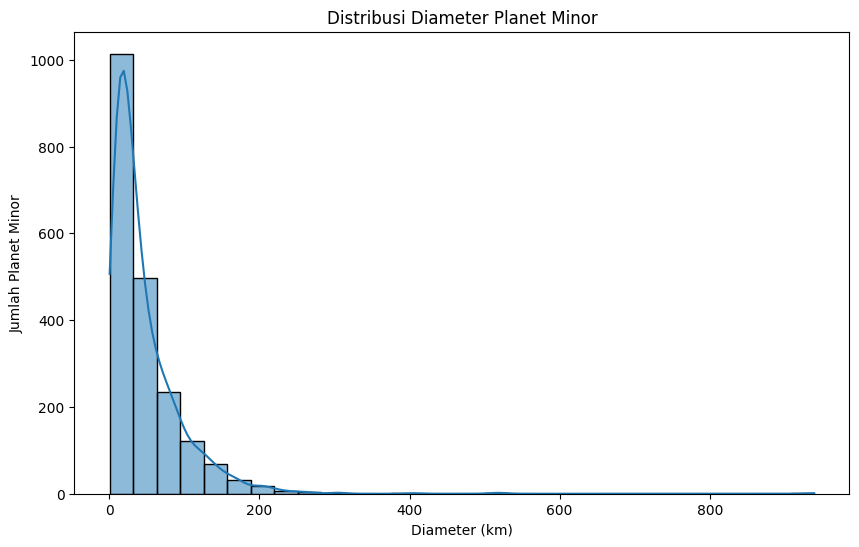

In [77]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="Diameter_km",
    bins=30,
    kde=True
)

plt.title("Distribusi Diameter Planet Minor")
plt.xlabel("Diameter (km)")
plt.ylabel("Jumlah Planet Minor")

plt.show()

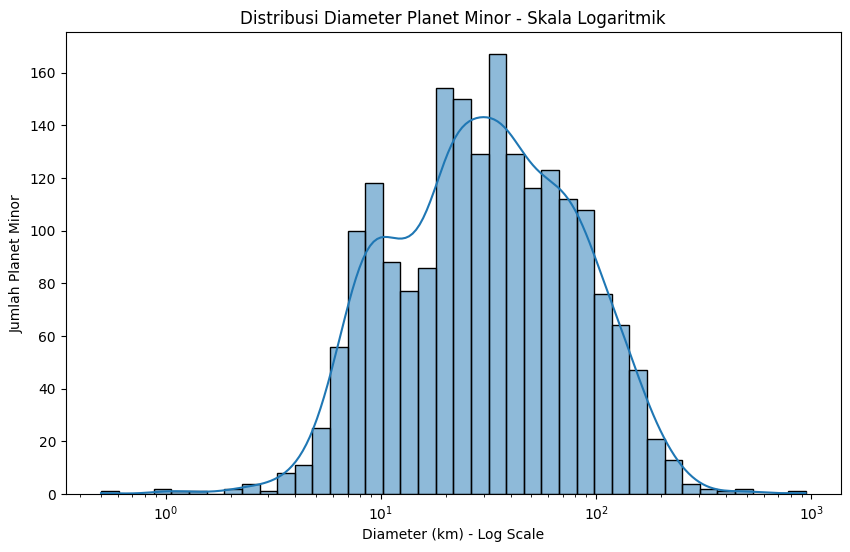

In [78]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="Diameter_km",
    bins=40,
    kde=True,
    log_scale=True
)

plt.title("Distribusi Diameter Planet Minor - Skala Logaritmik")
plt.xlabel("Diameter (km) - Log Scale")
plt.ylabel("Jumlah Planet Minor")

plt.show()

Histogram Discovery year

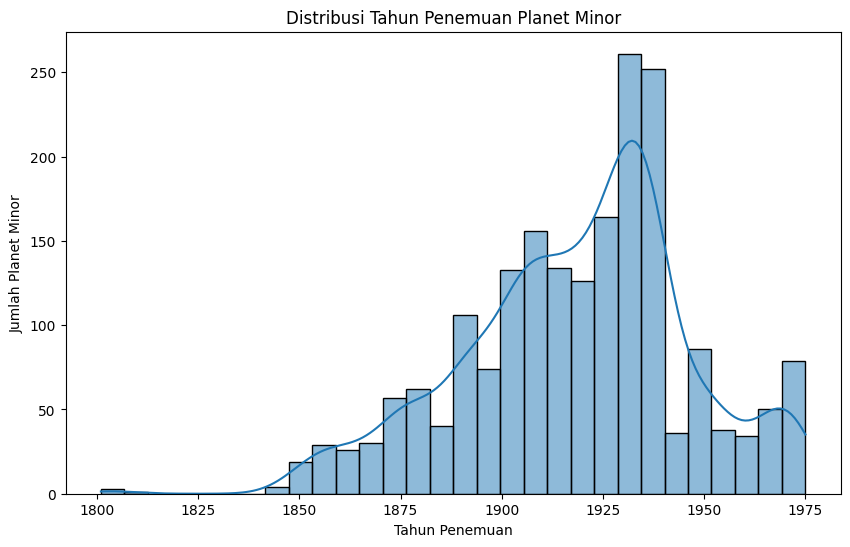

In [76]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="Discovery_Year",
    bins=30,
    kde=True
)

plt.title("Distribusi Tahun Penemuan Planet Minor")
plt.xlabel("Tahun Penemuan")
plt.ylabel("Jumlah Planet Minor")

plt.show()

Berdasarkan Histogram diatas, diketahui bahwa penemuan planet minor tidak merata

Bar chart Lokasi Penemuan

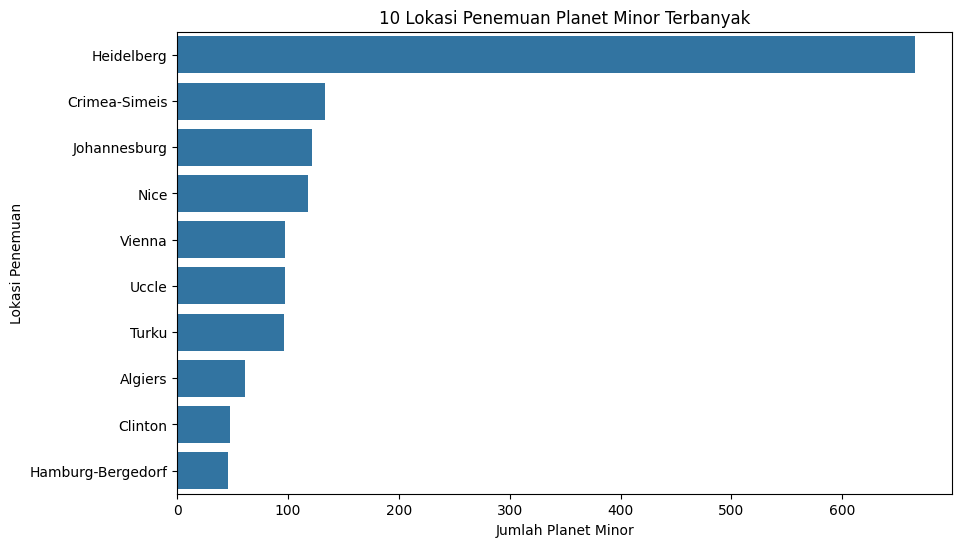

In [80]:
top_sites = df_clean["Discovery_Site"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_sites.values,
    y=top_sites.index
)

plt.title("10 Lokasi Penemuan Planet Minor Terbanyak")
plt.xlabel("Jumlah Planet Minor")
plt.ylabel("Lokasi Penemuan")

plt.show()

Top Discoverer

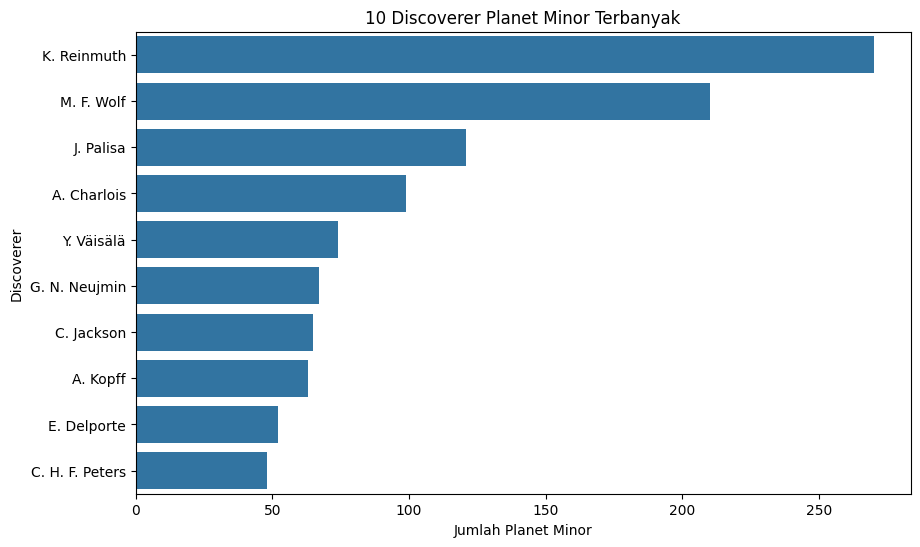

In [82]:
top_discoverers = df_clean["Discoverer"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_discoverers.values,
    y=top_discoverers.index
)

plt.title("10 Discoverer Planet Minor Terbanyak")
plt.xlabel("Jumlah Planet Minor")
plt.ylabel("Discoverer")

plt.show()

Boxplot Diameter

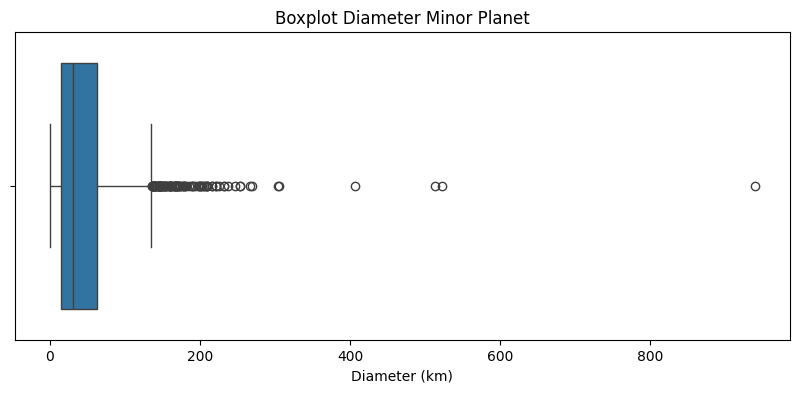

In [83]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_clean["Diameter_km"]
)

plt.title("Boxplot Diameter Minor Planet")
plt.xlabel("Diameter (km)")

plt.show()

**Interpretasi:**  
Boxplot menunjukkan adanya banyak nilai diameter yang berada di luar batas whisker. Hal tersebut konsisten dengan hasil perhitungan IQR sebelumnya. Outlier tetap dipertahankan karena merepresentasikan objek minor planet yang memang memiliki ukuran jauh lebih besar daripada mayoritas objek lainnya.

Scatter Plot Tahun Penemuan dengan Diameter Planet Minor

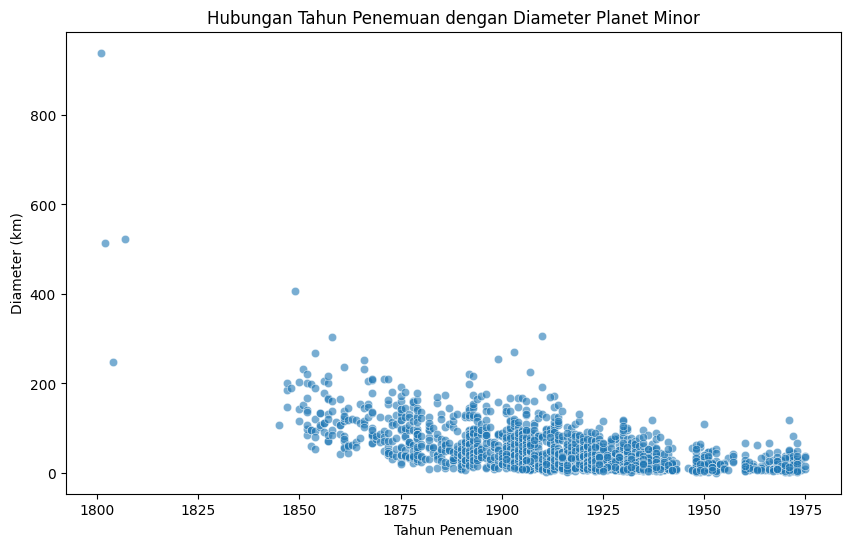

In [85]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="Discovery_Year",
    y="Diameter_km",
    alpha=0.6
)

plt.title("Hubungan Tahun Penemuan dengan Diameter Planet Minor")
plt.xlabel("Tahun Penemuan")
plt.ylabel("Diameter (km)")

plt.show()

Correlation heatmap

In [86]:
correlation_data = df_clean[
    [
        "Discovery_Year",
        "Diameter_km"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Discovery_Year,Diameter_km
Discovery_Year,1.000000,-0.602683
Diameter_km,-0.602683,1.000000


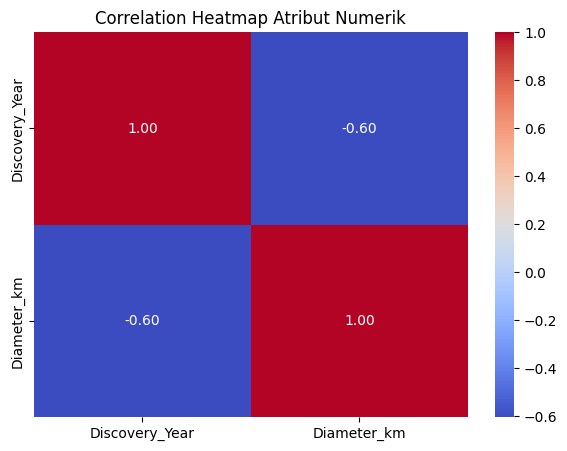

In [87]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap Atribut Numerik")

plt.show()

Diameter berdasarkan kategori

In [88]:
top_categories = (
    df_clean["Category"]
    .dropna()
    .value_counts()
    .head(5)
    .index
)

df_top_category = df_clean[
    df_clean["Category"].isin(top_categories)
]

print("Kategori yang digunakan:")
print(list(top_categories))

Kategori yang digunakan:
['EOS', 'slow', 'THM', 'KOR', 'PHO']


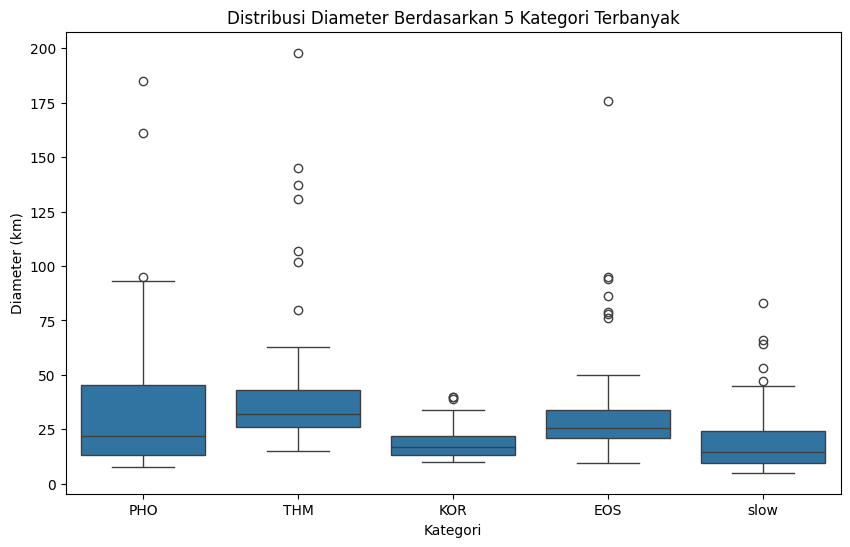

In [89]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_top_category,
    x="Category",
    y="Diameter_km"
)

plt.title("Distribusi Diameter Berdasarkan 5 Kategori Terbanyak")
plt.xlabel("Kategori")
plt.ylabel("Diameter (km)")

plt.show()

Validasi

In [90]:
print("===== VALIDASI DATASET AKHIR =====")

print("\nUkuran dataset:")
print(df_clean.shape)

print("\nJumlah missing value:")
print(df_clean.isnull().sum())

print("\nTipe data:")
print(df_clean.dtypes)

print("\nJumlah duplikat:")
print(df_clean.duplicated().sum())

===== VALIDASI DATASET AKHIR =====

Ukuran dataset:
(2000, 14)

Jumlah missing value:
Permanent               0
Provisional           331
Named_After             0
Discovery_Date          0
Discovery_Site          0
Discoverer              0
Category             1304
Diameter                0
Reference               0
Planet_Number           0
Planet_Name             0
Discovery_Year          0
Diameter_km             0
Category_Analysis       0
dtype: int64

Tipe data:
Permanent                    object
Provisional                  object
Named_After                  object
Discovery_Date       datetime64[ns]
Discovery_Site               object
Discoverer                   object
Category                     object
Diameter                     object
Reference                    object
Planet_Number                 Int64
Planet_Name                  object
Discovery_Year                int32
Diameter_km                 float64
Category_Analysis            object
dtype: object

Jumlah